# Phenolics Models and Visualization

## 1) Setup

In [1]:
from datetime import datetime
from pathlib import Path
import re
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from IPython.display import display
from patsy import dmatrix
from scipy import stats

ip = None
try:
    from IPython import get_ipython
    ip = get_ipython()
except Exception:
    ip = None
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')

ROOT = Path.cwd().resolve()
if not (ROOT / 'cranberry-data-group6').exists() and (ROOT.parent / 'cranberry-data-group6').exists():
    ROOT = ROOT.parent


def relpath(path: Path) -> str:
    try:
        return str(path.relative_to(ROOT))
    except ValueError:
        return str(path)


RAW_XLSX = ROOT / 'cranberry-data-group6' / 'data_mixed' / 'Phenolics_RawData.xlsx'
RESULT_DIR = ROOT / 'results' / 'phenolics'
FIG_DIR = RESULT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

LT_SUMMARY_OUT = RESULT_DIR / 'phenolics_longterm_summary.csv'
ACUTE_SUMMARY_OUT = RESULT_DIR / 'phenolics_acute_summary.csv'
LT_COEF_OUT = RESULT_DIR / 'phenolics_longterm_mixedlm_coefficients.csv'
ACUTE_COEF_OUT = RESULT_DIR / 'phenolics_acute_mixedlm_coefficients.csv'
LT_WALD_OUT = RESULT_DIR / 'phenolics_longterm_mixedlm_wald_terms.csv'
ACUTE_WALD_OUT = RESULT_DIR / 'phenolics_acute_mixedlm_wald_terms.csv'
REPORT_OUT = RESULT_DIR / 'phenolics_analysis_report.md'

FIG_LT_DIST = FIG_DIR / 'phenolics_longterm_distribution.png'
FIG_LT_MEAN = FIG_DIR / 'phenolics_longterm_mean_se.png'
FIG_LT_PRED = FIG_DIR / 'phenolics_longterm_mixedlm_fitted_means.png'
FIG_LT_DIAG = FIG_DIR / 'phenolics_longterm_diagnostics_mean_concentration.png'
FIG_AC_MEAN = FIG_DIR / 'phenolics_acute_mean_se.png'
FIG_AC_PRED = FIG_DIR / 'phenolics_acute_mixedlm_fitted_means.png'
FIG_AC_DIAG = FIG_DIR / 'phenolics_acute_diagnostics_mean_concentration.png'

STD_TUBES = {0, 50, 100, 150, 250, 500, 750}
REP_ABS_COLS = ['Rep1 Absorbance 765 nm', 'Rep2 Absorbance 765 nm', 'Rep3 Absorbance 765 nm']
REP_CONC_COLS = ['concentration_rep1', 'concentration_rep2', 'concentration_rep3']
CULTIVAR_ORDER = ['MQ', 'St']
LONGTERM_TREATMENT_ORDER = ['Control', 'OTC']
HEAT_LEVEL_ORDER = ['A', 'B', 'C', 'D']
CONDITION_ORDER = [0, 1]
CONDITION_LABELS = {0: 'Heated', 1: 'Control'}
CULTIVAR_COLORS = {'MQ': '#d95f02', 'St': '#1b9e77'}
CONDITION_COLORS = {0: '#d62728', 1: '#1f77b4'}

LT_SET_MAP = {
    ('St', 1): 7, ('St', 2): 8, ('St', 3): 9, ('St', 4): 10,
    ('St', 5): 7, ('St', 6): 8, ('St', 7): 9, ('St', 8): 10,
    ('MQ', 9): 11, ('MQ', 10): 12, ('MQ', 11): 13, ('MQ', 12): 14,
    ('MQ', 13): 11, ('MQ', 14): 12, ('MQ', 15): 13, ('MQ', 16): 14,
}

print('Project root detected.')
print(f'- {relpath(RAW_XLSX)} | exists={RAW_XLSX.exists()}')

Project root detected.
- cranberry-data-group6/data_mixed/Phenolics_RawData.xlsx | exists=True


In [2]:
def parse_sample_id(sample_id: str) -> dict[str, object] | None:
    s = str(sample_id).strip().upper()

    m = re.match(r'^(ST|MQ)LT(\d+)$', s)
    if m:
        cultivar = 'St' if m.group(1) == 'ST' else 'MQ'
        plot_id = int(m.group(2))
        if cultivar == 'St':
            heat_trt = 'OTC' if plot_id in {1, 2, 3, 4} else 'Control'
        else:
            heat_trt = 'OTC' if plot_id in {9, 10, 11, 12} else 'Control'
        return {
            'experiment': 'longterm',
            'cultivar': cultivar,
            'plot_id': plot_id,
            'set_id': LT_SET_MAP.get((cultivar, plot_id)),
            'treatment_raw': heat_trt,
            'heat_level': np.nan,
            'is_control': 1 if heat_trt == 'Control' else 0,
            'replicate': np.nan,
        }

    m = re.match(r'^(ST|MQ)(A0C|A0|AC|A|BC|B|CC|C|DC|CD|D)(\d+)$', s)
    if m:
        cultivar = 'St' if m.group(1) == 'ST' else 'MQ'
        trt = m.group(2)
        replicate = int(m.group(3))

        if trt == 'CD':
            trt = 'DC'

        control_tokens = {'A0C', 'AC', 'BC', 'CC', 'DC'}
        if trt in control_tokens:
            is_control = 1
            heat_level = trt[:-1]
        else:
            is_control = 0
            heat_level = trt

        return {
            'experiment': 'acute',
            'cultivar': cultivar,
            'plot_id': np.nan,
            'set_id': np.nan,
            'treatment_raw': trt,
            'heat_level': heat_level,
            'is_control': is_control,
            'replicate': replicate,
        }

    return None


def mean_se_frame(df: pd.DataFrame, group_cols: list[str], outcome: str) -> pd.DataFrame:
    out = (
        df.groupby(group_cols, observed=False)[outcome]
        .agg(['mean', 'std', 'count'])
        .reset_index()
    )
    out['se'] = out['std'] / np.sqrt(out['count'])
    out['ci_low'] = out['mean'] - 1.96 * out['se']
    out['ci_high'] = out['mean'] + 1.96 * out['se']
    out['outcome'] = outcome
    return out


def paired_ttest_table(df: pd.DataFrame, group_cols: list[str], value_col: str) -> pd.DataFrame:
    rows = []
    grouped = [(("overall",), df)] if not group_cols else list(df.groupby(group_cols))
    for key, sub in grouped:
        if not isinstance(key, tuple):
            key = (key,)
        vals = sub[value_col].dropna().to_numpy(dtype=float)
        if len(vals) < 2:
            t_stat, p_value, se = np.nan, np.nan, np.nan
        else:
            t_stat, p_value = stats.ttest_1samp(vals, 0.0)
            se = vals.std(ddof=1) / np.sqrt(len(vals))
        row = {
            'n_pairs': int(len(vals)),
            'mean_diff_heat_minus_control': float(np.nanmean(vals)) if len(vals) else np.nan,
            'sd_diff': float(np.nanstd(vals, ddof=1)) if len(vals) > 1 else np.nan,
            'se_diff': se,
            't_stat': t_stat,
            'p_value': p_value,
        }
        for col, value in zip(group_cols, key):
            row[col] = value
        rows.append(row)
    cols = group_cols + ['n_pairs', 'mean_diff_heat_minus_control', 'sd_diff', 'se_diff', 't_stat', 'p_value']
    return pd.DataFrame(rows)[cols]


def fit_mixedlm(formula: str, data: pd.DataFrame, group_col: str):
    methods = ['lbfgs', 'powell', 'cg', 'nm']
    fallback = None
    errors = []
    for method in methods:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                model = smf.mixedlm(formula, data=data, groups=data[group_col]).fit(
                    reml=False,
                    method=method,
                    maxiter=1000,
                    disp=False,
                )
            if model.converged:
                return model, method
            if fallback is None:
                fallback = (model, method)
        except Exception as exc:
            errors.append(f'{method}: {exc}')
    if fallback is not None:
        return fallback
    raise RuntimeError('MixedLM failed for all optimizers: ' + ' | '.join(errors))


def fixed_effect_predictions(model, grid: pd.DataFrame) -> pd.DataFrame:
    fe_names = model.fe_params.index.tolist()
    X = dmatrix(model.model.data.design_info, grid, return_type='dataframe')
    X = X[fe_names]
    beta = model.fe_params.loc[fe_names].to_numpy()
    cov = model.cov_params().loc[fe_names, fe_names].to_numpy()
    xmat = X.to_numpy()
    pred = xmat @ beta
    se = np.sqrt(np.einsum('ij,jk,ik->i', xmat, cov, xmat))
    out = grid.copy()
    out['pred'] = pred
    out['se'] = se
    out['ci_low'] = pred - 1.96 * se
    out['ci_high'] = pred + 1.96 * se
    return out


def mixedlm_coefficient_table(model, model_name: str, optimizer: str) -> pd.DataFrame:
    ci = model.conf_int()
    return pd.DataFrame(
        {
            'model_name': model_name,
            'optimizer': optimizer,
            'term': model.params.index,
            'estimate': model.params.values,
            'std_error': model.bse.values,
            'z_value': model.tvalues.values,
            'p_value': model.pvalues.values,
            'ci_low': ci[0].values,
            'ci_high': ci[1].values,
            'n_obs': int(model.nobs),
            'n_groups': int(len(model.model.group_labels)),
            'converged': bool(model.converged),
            'log_likelihood': float(model.llf),
            'aic': float(model.aic),
            'bic': float(model.bic),
        }
    )


def mixedlm_wald_terms_table(model, model_name: str) -> pd.DataFrame:
    table = model.wald_test_terms(skip_single=False).table.reset_index().rename(columns={'index': 'term'})
    p_col = 'pvalue' if 'pvalue' in table.columns else 'p_value'
    return pd.DataFrame(
        {
            'model_name': model_name,
            'term': table['term'],
            'statistic': table['statistic'].map(lambda x: float(np.asarray(x).reshape(-1)[0])),
            'df_constraint': table['df_constraint'].map(lambda x: float(np.asarray(x).reshape(-1)[0])),
            'p_value': table[p_col].map(lambda x: float(np.asarray(x).reshape(-1)[0])),
        }
    )


def diagnostic_figure(model, title_prefix: str):
    fitted = np.asarray(model.fittedvalues)
    resid = np.asarray(model.resid)
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].scatter(fitted, resid, color='darkblue', alpha=0.8)
    axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
    axes[0].set_title(f'{title_prefix}: Residuals vs Fitted')
    axes[0].set_xlabel('Fitted values')
    axes[0].set_ylabel('Residuals')
    axes[0].grid(alpha=0.2)

    stats.probplot(resid, dist='norm', plot=axes[1])
    axes[1].set_title(f'{title_prefix}: QQ Plot')
    axes[1].grid(alpha=0.2)
    fig.tight_layout()
    return fig


def best_term_line(df: pd.DataFrame, label: str) -> str:
    sub = df[df['term'] != 'Intercept'].dropna(subset=['p_value']).copy()
    if sub.empty:
        return f'- {label}: no valid term test'
    best = sub.sort_values('p_value', ascending=True).iloc[0]
    return f"- {label}: smallest term p={best['p_value']:.4g} ({best['term']})"


## 2) Data preprocessing

In [3]:
raw = pd.read_excel(RAW_XLSX, sheet_name='Absorbance Data').copy()
raw['sample_id_clean'] = raw['Sample ID'].astype(str).str.strip()
raw['tube_num'] = pd.to_numeric(raw['Tube#'], errors='coerce')
raw['date_key'] = pd.to_datetime(raw['Date'], errors='coerce').dt.normalize()
raw['is_standard'] = raw['sample_id_clean'].str.match(r'(?i)^std\d+$', na=False) & raw['tube_num'].isin(STD_TUBES)

print('Raw rows:', len(raw))
print('Standard rows:', int(raw['is_standard'].sum()))
print('Non-standard rows:', int((~raw['is_standard']).sum()))

std_like_nonstd = raw[
    raw['sample_id_clean'].str.match(r'(?i)^std\d+$', na=False)
    & ~raw['tube_num'].isin(STD_TUBES)
].copy()
print('Std-like IDs that are NOT true standards:', len(std_like_nonstd))
display(std_like_nonstd[['Date', 'Sample ID', 'Tube#']])

Raw rows: 128
Standard rows: 49
Non-standard rows: 79
Std-like IDs that are NOT true standards: 3


,Date,Sample ID,Tube#
21,2025-01-07,STD1,8
48,2025-01-08,STD3,28
97,2025-01-13,STD2,63


In [4]:
calibration_rows = []
calibration_lookup = {}

std = raw[raw['is_standard']].copy()
for rep_idx, abs_col in enumerate(REP_ABS_COLS, start=1):
    for date, sub in std.groupby('date_key'):
        x = pd.to_numeric(sub['tube_num'], errors='coerce').to_numpy(dtype=float)
        y = pd.to_numeric(sub[abs_col], errors='coerce').to_numpy(dtype=float)
        keep = np.isfinite(x) & np.isfinite(y)
        x = x[keep]
        y = y[keep]

        if len(x) < 2:
            m, b = np.nan, np.nan
        else:
            m, b = np.polyfit(x, y, 1)

        calibration_lookup[(date, rep_idx)] = (float(m), float(b))
        calibration_rows.append(
            {
                'Date': date,
                'replicate': rep_idx,
                'n_standards': int(len(x)),
                'slope_m': float(m),
                'intercept_b': float(b),
            }
        )

calibration_summary = pd.DataFrame(calibration_rows).sort_values(['Date', 'replicate']).reset_index(drop=True)
print('Calibration lines:', len(calibration_summary))
display(calibration_summary)

Calibration lines: 21


,Date,replicate,n_standards,slope_m,intercept_b
0,2025-01-06,1,7,0.000981,0.019741
1,2025-01-06,2,7,0.001025,0.027968
2,2025-01-06,3,7,0.001081,0.012508
3,2025-01-07,1,7,0.000949,0.027288
4,2025-01-07,2,7,0.001025,0.011029
5,2025-01-07,3,7,0.001028,0.014722
6,2025-01-08,1,7,0.000999,0.006875
7,2025-01-08,2,7,0.001014,0.008022
8,2025-01-08,3,7,0.001017,0.000013
9,2025-01-09,1,7,0.001004,-0.006946


In [5]:
nonstd = raw[~raw['is_standard']].copy().reset_index(drop=True)

for rep_idx, abs_col in enumerate(REP_ABS_COLS, start=1):
    out_col = REP_CONC_COLS[rep_idx - 1]
    vals = []
    for _, r in nonstd.iterrows():
        m, b = calibration_lookup.get((r['date_key'], rep_idx), (np.nan, np.nan))
        y = pd.to_numeric(r[abs_col], errors='coerce')
        if (not np.isfinite(m)) or (m == 0) or (not np.isfinite(y)):
            vals.append(np.nan)
        else:
            vals.append(((y - b) / m) * 10.0)
    nonstd[out_col] = vals

concentrations = nonstd[['date_key', 'Sample ID', 'Tube#'] + REP_CONC_COLS].copy()
concentrations = concentrations.rename(columns={'date_key': 'Date'})
concentrations['Date'] = pd.to_datetime(concentrations['Date'], errors='coerce').dt.strftime('%Y-%m-%d')

print('Output rows (non-standard only):', len(concentrations))
print('Missing concentration cells:', int(concentrations[REP_CONC_COLS].isna().sum().sum()))
display(concentrations.head(12))

Output rows (non-standard only): 79
Missing concentration cells: 0


,Date,Sample ID,Tube#,concentration_rep1,concentration_rep2,concentration_rep3
0,2025-01-06,STB3,1,1511.292765,1288.658829,1308.466163
1,2025-01-06,MQBC2,2,2214.652098,1308.179239,2353.448658
2,2025-01-06,MQLT16,3,1888.456465,2596.526240,1641.380940
3,2025-01-06,STA0C1,4,991.418476,1015.373102,2205.486535
4,2025-01-06,MQA03,5,1409.356630,1776.669057,2048.276779
5,2025-01-06,MQAC1,6,1970.005374,2147.556831,1752.352533
6,2025-01-06,MQCC1,7,1654.003354,1425.301693,1576.647512
7,2025-01-07,STD1,8,1187.845118,1658.436984,1627.617079
8,2025-01-07,MQLT9,9,1746.397306,1473.050906,1705.457202
9,2025-01-07,STLT6,10,1303.771044,1531.593878,1637.347094


In [6]:
parsed = concentrations['Sample ID'].apply(parse_sample_id)
parsed_df = pd.DataFrame([x if isinstance(x, dict) else {} for x in parsed])

phen = pd.concat([concentrations, parsed_df], axis=1)
phen['mean_concentration'] = phen[REP_CONC_COLS].mean(axis=1, skipna=True)

print('Rows parsed successfully:', int(phen['experiment'].notna().sum()), '/', len(phen))
print('Rows by experiment:')
print(phen['experiment'].value_counts(dropna=False))
display(phen[['Date', 'Sample ID', 'experiment', 'cultivar', 'treatment_raw', 'heat_level', 'is_control', 'replicate', 'mean_concentration']].head(20))

Rows parsed successfully: 79 / 79
Rows by experiment:
experiment
acute       63
longterm    16
Name: count, dtype: int64


,Date,Sample ID,experiment,cultivar,treatment_raw,heat_level,is_control,replicate,mean_concentration
0,2025-01-06,STB3,acute,St,B,B,0,3.0,1369.472586
1,2025-01-06,MQBC2,acute,MQ,BC,B,1,2.0,1958.759998
2,2025-01-06,MQLT16,longterm,MQ,Control,NaN,1,NaN,2042.121215
3,2025-01-06,STA0C1,acute,St,A0C,A0,1,1.0,1404.092704
4,2025-01-06,MQA03,acute,MQ,A0,A0,0,3.0,1744.767489
5,2025-01-06,MQAC1,acute,MQ,AC,A,1,1.0,1956.638246
6,2025-01-06,MQCC1,acute,MQ,CC,C,1,1.0,1551.984186
7,2025-01-07,STD1,acute,St,D,D,0,1.0,1491.299727
8,2025-01-07,MQLT9,longterm,MQ,OTC,NaN,0,NaN,1641.635138
9,2025-01-07,STLT6,longterm,St,Control,NaN,1,NaN,1490.904005


In [7]:
# Long-term paired table
lt = phen[phen['experiment'] == 'longterm'].copy()
lt_agg = (
    lt.groupby(['cultivar', 'set_id', 'treatment_raw'], as_index=False)['mean_concentration']
    .mean()
)
lt_pairs = (
    lt_agg.pivot(index=['cultivar', 'set_id'], columns='treatment_raw', values='mean_concentration')
    .reset_index()
    .rename_axis(columns=None)
)
lt_pairs['concentration_diff'] = lt_pairs['OTC'] - lt_pairs['Control']

# Acute paired table (exclude A0 / A0C from main treatment-effect analysis)
acute = phen[(phen['experiment'] == 'acute') & (phen['heat_level'] != 'A0')].copy()
acute_agg = (
    acute.groupby(['cultivar', 'heat_level', 'replicate', 'is_control'], as_index=False)['mean_concentration']
    .mean()
)
acute_pairs = (
    acute_agg.pivot(index=['cultivar', 'heat_level', 'replicate'], columns='is_control', values='mean_concentration')
    .reset_index()
    .rename_axis(columns=None)
    .rename(columns={0: 'heat', 1: 'control'})
)
acute_pairs['concentration_diff'] = acute_pairs['heat'] - acute_pairs['control']
acute_pairs['complete_pair'] = acute_pairs[['heat', 'control']].notna().all(axis=1).astype(int)

lt_complete = lt_pairs.dropna(subset=['concentration_diff']).copy()
acute_complete = acute_pairs[acute_pairs['complete_pair'] == 1].copy()

lt_summary = pd.concat([
    paired_ttest_table(lt_complete, [], 'concentration_diff'),
    paired_ttest_table(lt_complete, ['cultivar'], 'concentration_diff')
], ignore_index=True, sort=False)

acute_summary = pd.concat([
    paired_ttest_table(acute_complete, ['heat_level'], 'concentration_diff'),
    paired_ttest_table(acute_complete, ['cultivar', 'heat_level'], 'concentration_diff')
], ignore_index=True, sort=False)

print('Long-term complete pairs:', len(lt_complete))
print('Acute complete pairs:', len(acute_complete))
print()
print('Long-term paired summary:')
display(lt_summary)
print('Acute paired summary:')
display(acute_summary)


Long-term complete pairs: 8
Acute complete pairs: 24

Long-term paired summary:


,n_pairs,mean_diff_heat_minus_control,sd_diff,se_diff,t_stat,p_value,cultivar
0,8,40.957975,273.689264,96.763767,0.423278,0.684794,NaN
1,4,206.523935,226.510349,113.255175,1.823528,0.165736,MQ
2,4,-124.607984,224.442406,112.221203,-1.110378,0.347830,St


Acute paired summary:


,heat_level,n_pairs,mean_diff_heat_minus_control,sd_diff,se_diff,t_stat,p_value,cultivar
0,A,6,8.168373,639.751417,261.177423,0.031275,0.976260,NaN
1,B,6,-54.569416,199.428603,81.416386,-0.670251,0.532404,NaN
2,C,6,-84.880297,318.895467,130.188529,-0.651980,0.543192,NaN
3,D,6,-150.904522,189.092593,77.196728,-1.954805,0.108004,NaN
4,A,3,-335.420501,658.337583,380.091381,-0.882473,0.470610,MQ
5,B,3,-129.545867,87.683743,50.624233,-2.558969,0.124765,MQ
6,C,3,14.932475,451.785496,260.838478,0.057248,0.959553,MQ
7,D,3,-191.496203,279.382833,161.301754,-1.187192,0.357045,MQ
8,A,3,351.757248,485.423911,280.259626,1.255112,0.336217,St
9,B,3,20.407034,273.635845,157.983729,0.129172,0.909040,St


## 3) Long-term visualization

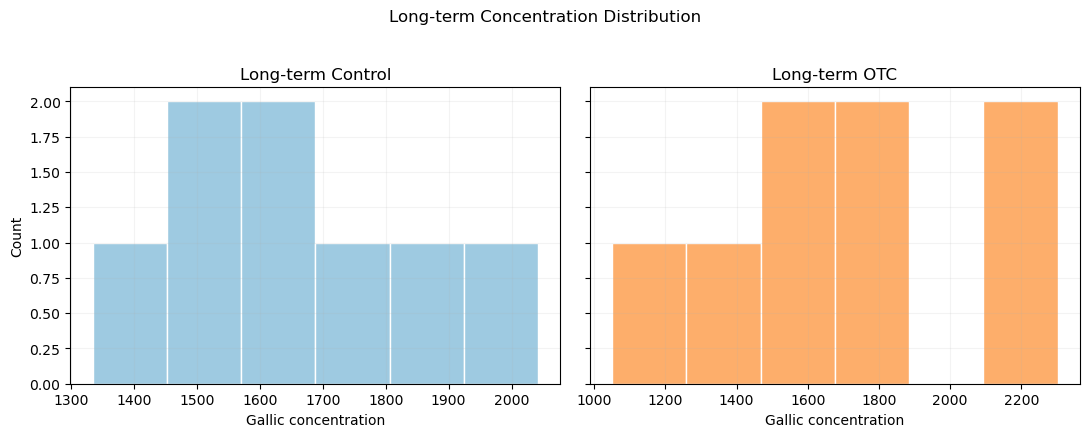

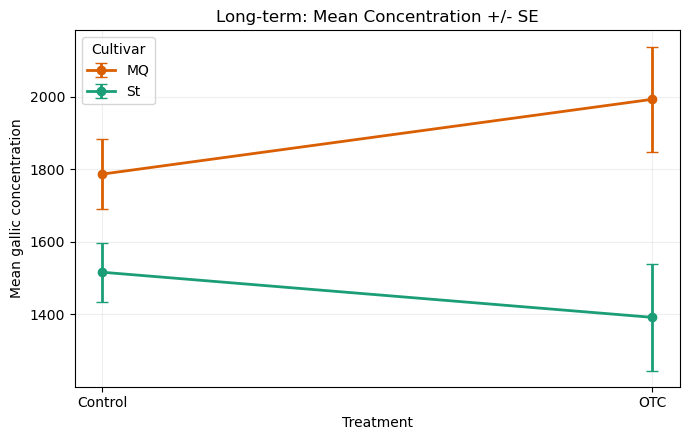

In [8]:
lt_keep = lt.dropna(subset=['mean_concentration', 'cultivar', 'treatment_raw', 'set_id']).copy()
lt_keep['set_id'] = pd.to_numeric(lt_keep['set_id'], errors='coerce').astype('Int64')
lt_keep = lt_keep[lt_keep['set_id'].notna()].copy()
lt_keep['set_key'] = lt_keep['cultivar'].astype(str) + '_' + lt_keep['set_id'].astype(str)

fig_lt_dist, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, treatment in zip(axes, LONGTERM_TREATMENT_ORDER):
    sub = lt_keep[lt_keep['treatment_raw'] == treatment]
    ax.hist(sub['mean_concentration'].dropna(), bins=6, color='#9ecae1' if treatment == 'Control' else '#fdae6b', edgecolor='white')
    ax.set_title(f'Long-term {treatment}')
    ax.set_xlabel('Gallic concentration')
    ax.grid(alpha=0.15)
axes[0].set_ylabel('Count')
fig_lt_dist.suptitle('Long-term Concentration Distribution', y=1.03)
fig_lt_dist.tight_layout()
fig_lt_dist.savefig(FIG_LT_DIST, dpi=180, bbox_inches='tight')
plt.show()

lt_mean_se = mean_se_frame(lt_keep, ['cultivar', 'treatment_raw'], 'mean_concentration')
fig_lt_mean, ax = plt.subplots(figsize=(7, 4.5))
for cultivar in CULTIVAR_ORDER:
    sub = lt_mean_se[lt_mean_se['cultivar'] == cultivar].copy()
    sub['treatment_raw'] = pd.Categorical(sub['treatment_raw'], categories=LONGTERM_TREATMENT_ORDER, ordered=True)
    sub = sub.sort_values('treatment_raw')
    x = np.arange(len(sub))
    ax.errorbar(
        x,
        sub['mean'],
        yerr=sub['se'],
        marker='o',
        linewidth=2,
        capsize=4,
        color=CULTIVAR_COLORS[cultivar],
        label=cultivar,
    )
ax.set_xticks([0, 1])
ax.set_xticklabels(LONGTERM_TREATMENT_ORDER)
ax.set_xlabel('Treatment')
ax.set_ylabel('Mean gallic concentration')
ax.set_title('Long-term: Mean Concentration +/- SE')
ax.legend(title='Cultivar', loc='best')
ax.grid(alpha=0.2)
fig_lt_mean.tight_layout()
fig_lt_mean.savefig(FIG_LT_MEAN, dpi=180, bbox_inches='tight')
plt.show()

## 4) Long-term models and ANOVA-style tests

In [9]:
lt_model, lt_optimizer = fit_mixedlm(
    'mean_concentration ~ C(cultivar) * C(treatment_raw)',
    lt_keep,
    'set_key',
)
lt_coef = mixedlm_coefficient_table(lt_model, 'longterm_mixedlm', lt_optimizer)
lt_terms = mixedlm_wald_terms_table(lt_model, 'longterm_mixedlm')

print('Long-term coefficient table')
display(lt_coef)
print('Long-term Wald term tests (Python analogue of ANOVA)')
display(lt_terms)

Long-term coefficient table


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1906: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


,model_name,optimizer,term,estimate,std_error,z_value,p_value,ci_low,ci_high,n_obs,n_groups,converged,log_likelihood,aic,bic
0,longterm_mixedlm,lbfgs,Intercept,1787.075182,104.871753,17.040577,4.106602e-65,1581.530323,1992.620041,16,8,True,-106.688282,225.376565,230.012097
1,longterm_mixedlm,lbfgs,C(cultivar)[T.St],-270.847002,148.311056,-1.826209,6.781877e-02,-561.531330,19.837325,16,8,True,-106.688282,225.376565,230.012097
2,longterm_mixedlm,lbfgs,C(treatment_raw)[T.OTC],206.523935,97.635198,2.115261,3.440770e-02,15.162464,397.885406,16,8,True,-106.688282,225.376565,230.012097
3,longterm_mixedlm,lbfgs,C(cultivar)[T.St]:C(treatment_raw)[T.OTC],-331.131919,138.077021,-2.398168,1.647730e-02,-601.757908,-60.505931,16,8,True,-106.688282,225.376565,230.012097
4,longterm_mixedlm,lbfgs,Group Var,1.307460,1.278066,1.022999,3.063085e-01,-1.197504,3.812425,16,8,True,-106.688282,225.376565,230.012097


Long-term Wald term tests (Python analogue of ANOVA)


,model_name,term,statistic,df_constraint,p_value
0,longterm_mixedlm,Intercept,290.381264,1.0,4.106602e-65
1,longterm_mixedlm,C(cultivar),3.335040,1.0,6.781877e-02
2,longterm_mixedlm,C(treatment_raw),4.474329,1.0,3.440770e-02
3,longterm_mixedlm,C(cultivar):C(treatment_raw),5.751211,1.0,1.647730e-02


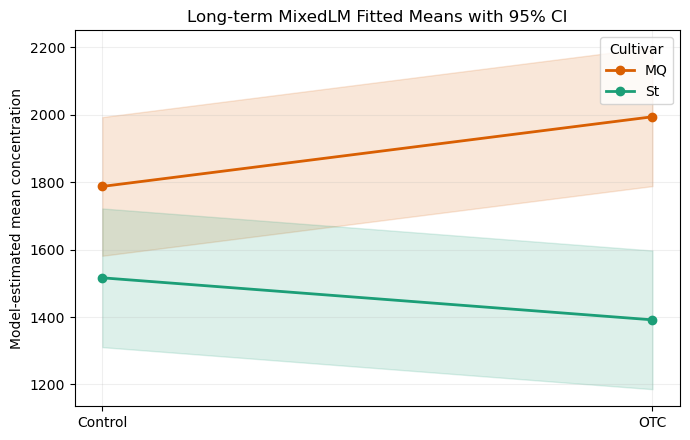

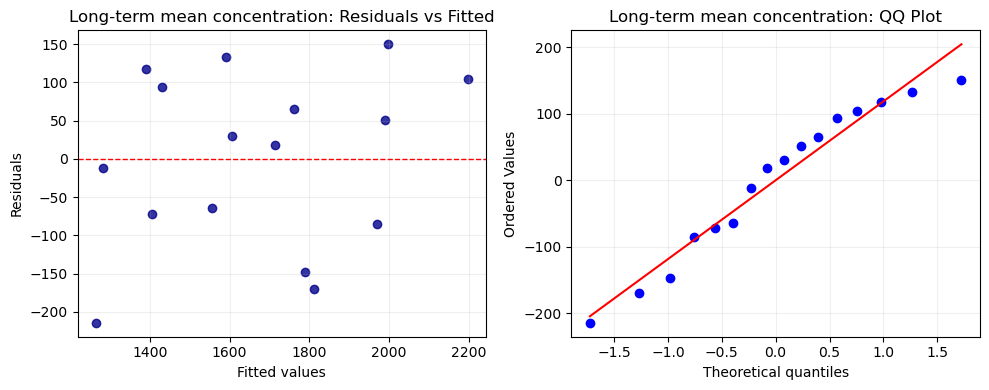

In [10]:
lt_grid = pd.DataFrame(
    [
        {'cultivar': cultivar, 'treatment_raw': treatment}
        for cultivar in CULTIVAR_ORDER
        for treatment in LONGTERM_TREATMENT_ORDER
    ]
)
lt_pred = fixed_effect_predictions(lt_model, lt_grid)

fig_lt_pred, ax = plt.subplots(figsize=(7, 4.5))
for cultivar in CULTIVAR_ORDER:
    curve = lt_pred[lt_pred['cultivar'] == cultivar].copy()
    curve['treatment_raw'] = pd.Categorical(curve['treatment_raw'], categories=LONGTERM_TREATMENT_ORDER, ordered=True)
    curve = curve.sort_values('treatment_raw')
    x = np.arange(len(curve))
    ax.plot(x, curve['pred'], marker='o', linewidth=2, color=CULTIVAR_COLORS[cultivar], label=cultivar)
    ax.fill_between(x, curve['ci_low'], curve['ci_high'], color=CULTIVAR_COLORS[cultivar], alpha=0.15)
ax.set_xticks([0, 1])
ax.set_xticklabels(LONGTERM_TREATMENT_ORDER)
ax.set_ylabel('Model-estimated mean concentration')
ax.set_title('Long-term MixedLM Fitted Means with 95% CI')
ax.legend(title='Cultivar', loc='best')
ax.grid(alpha=0.2)
fig_lt_pred.tight_layout()
fig_lt_pred.savefig(FIG_LT_PRED, dpi=180, bbox_inches='tight')
plt.show()

fig_lt_diag = diagnostic_figure(lt_model, 'Long-term mean concentration')
fig_lt_diag.savefig(FIG_LT_DIAG, dpi=180, bbox_inches='tight')
plt.show()

## 5) Acute visualization

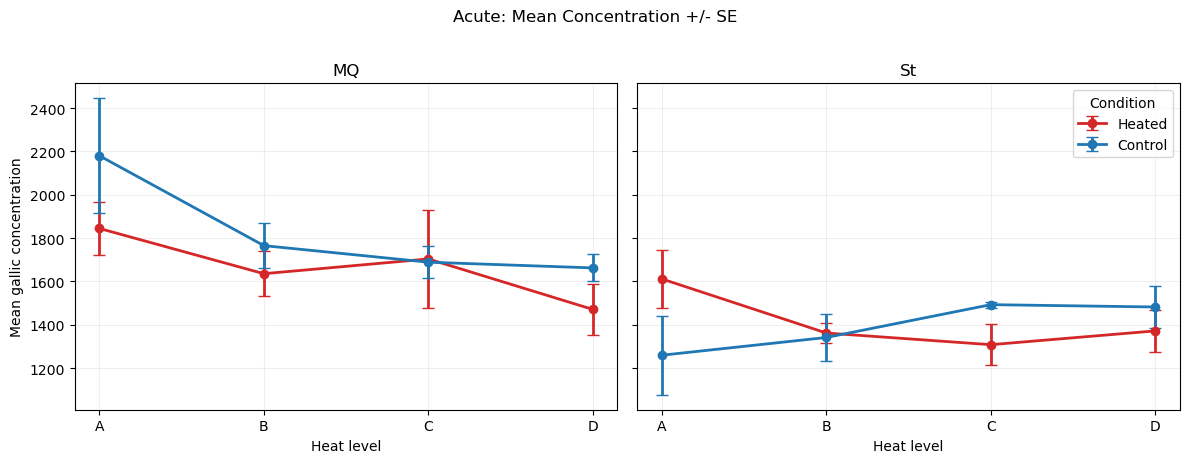

In [11]:
acute_keep = acute_agg.merge(
    acute_complete[['cultivar', 'heat_level', 'replicate']].drop_duplicates(),
    on=['cultivar', 'heat_level', 'replicate'],
    how='inner',
).dropna(subset=['mean_concentration']).copy()
acute_keep['pair_id'] = (
    acute_keep['cultivar'].astype(str)
    + '_'
    + acute_keep['heat_level'].astype(str)
    + '_'
    + acute_keep['replicate'].astype(str)
)

acute_mean_se = mean_se_frame(acute_keep, ['cultivar', 'heat_level', 'is_control'], 'mean_concentration')
fig_ac_mean, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, cultivar in zip(axes, CULTIVAR_ORDER):
    sub = acute_mean_se[acute_mean_se['cultivar'] == cultivar].copy()
    for is_control in CONDITION_ORDER:
        curve = sub[sub['is_control'] == is_control].copy()
        curve['heat_level'] = pd.Categorical(curve['heat_level'], categories=HEAT_LEVEL_ORDER, ordered=True)
        curve = curve.sort_values('heat_level')
        x = np.arange(len(curve))
        ax.errorbar(
            x,
            curve['mean'],
            yerr=curve['se'],
            marker='o',
            linewidth=2,
            capsize=4,
            color=CONDITION_COLORS[is_control],
            label=CONDITION_LABELS[is_control],
        )
    ax.set_xticks(np.arange(len(HEAT_LEVEL_ORDER)))
    ax.set_xticklabels(HEAT_LEVEL_ORDER)
    ax.set_xlabel('Heat level')
    ax.set_title(cultivar)
    ax.grid(alpha=0.2)
axes[0].set_ylabel('Mean gallic concentration')
axes[1].legend(title='Condition', loc='best')
fig_ac_mean.suptitle('Acute: Mean Concentration +/- SE', y=1.02)
fig_ac_mean.tight_layout()
fig_ac_mean.savefig(FIG_AC_MEAN, dpi=180, bbox_inches='tight')
plt.show()

## 6) Acute models and ANOVA-style tests

In [12]:
acute_model, acute_optimizer = fit_mixedlm(
    'mean_concentration ~ C(heat_level) * C(cultivar) * C(is_control)',
    acute_keep,
    'pair_id',
)
acute_coef = mixedlm_coefficient_table(acute_model, 'acute_mixedlm', acute_optimizer)
acute_terms = mixedlm_wald_terms_table(acute_model, 'acute_mixedlm')

print('Acute coefficient table')
display(acute_coef)
print('Acute Wald term tests (Python analogue of ANOVA)')
display(acute_terms)

Acute coefficient table


/opt/anaconda3/lib/python3.11/site-packages/statsmodels/base/model.py:1906: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


,model_name,optimizer,term,estimate,std_error,z_value,p_value,ci_low,ci_high,n_obs,n_groups,converged,log_likelihood,aic,bic
0,acute_mixedlm,lbfgs,Intercept,1844.171359,107.801496,17.107104,1.313717e-65,1632.884309,2055.458408,48,24,True,-319.111836,674.223672,707.90529
1,acute_mixedlm,lbfgs,C(heat_level)[T.B],-208.769222,152.454338,-1.369389,1.708779e-01,-507.574233,90.035788,48,24,True,-319.111836,674.223672,707.90529
2,acute_mixedlm,lbfgs,C(heat_level)[T.C],-140.690166,152.454338,-0.922835,3.560933e-01,-439.495177,158.114845,48,24,True,-319.111836,674.223672,707.90529
3,acute_mixedlm,lbfgs,C(heat_level)[T.D],-373.512377,152.454338,-2.449995,1.428582e-02,-672.317388,-74.707366,48,24,True,-319.111836,674.223672,707.90529
4,acute_mixedlm,lbfgs,C(cultivar)[T.St],-233.048293,152.454338,-1.528643,1.263529e-01,-531.853304,65.756718,48,24,True,-319.111836,674.223672,707.90529
5,acute_mixedlm,lbfgs,C(is_control)[T.1],335.420501,149.482225,2.243882,2.483998e-02,42.440725,628.400278,48,24,True,-319.111836,674.223672,707.90529
6,acute_mixedlm,lbfgs,C(heat_level)[T.B]:C(cultivar)[T.St],-40.740887,215.602992,-0.188963,8.501222e-01,-463.314985,381.833212,48,24,True,-319.111836,674.223672,707.90529
7,acute_mixedlm,lbfgs,C(heat_level)[T.C]:C(cultivar)[T.St],-162.516027,215.602992,-0.753774,4.509847e-01,-585.090125,260.058072,48,24,True,-319.111836,674.223672,707.90529
8,acute_mixedlm,lbfgs,C(heat_level)[T.D]:C(cultivar)[T.St],133.887005,215.602992,0.620989,5.346071e-01,-288.687094,556.461104,48,24,True,-319.111836,674.223672,707.90529
9,acute_mixedlm,lbfgs,C(heat_level)[T.B]:C(is_control)[T.1],-205.874634,211.399789,-0.973864,3.301241e-01,-620.210608,208.461339,48,24,True,-319.111836,674.223672,707.90529


Acute Wald term tests (Python analogue of ANOVA)


,model_name,term,statistic,df_constraint,p_value
0,acute_mixedlm,Intercept,292.652994,1.0,1.313717e-65
1,acute_mixedlm,C(heat_level),6.214332,3.0,1.016356e-01
2,acute_mixedlm,C(cultivar),2.336750,1.0,1.263529e-01
3,acute_mixedlm,C(is_control),5.035007,1.0,2.483998e-02
4,acute_mixedlm,C(heat_level):C(cultivar),1.927258,3.0,5.876409e-01
5,acute_mixedlm,C(heat_level):C(is_control),2.832526,3.0,4.181736e-01
6,acute_mixedlm,C(cultivar):C(is_control),10.566449,1.0,1.151587e-03
7,acute_mixedlm,C(heat_level):C(cultivar):C(is_control),9.219359,3.0,2.651218e-02


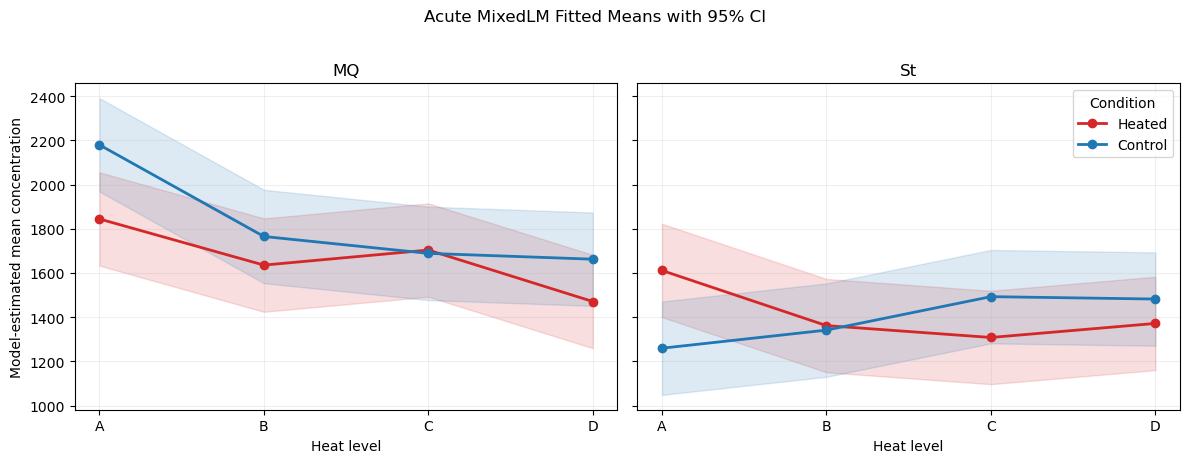

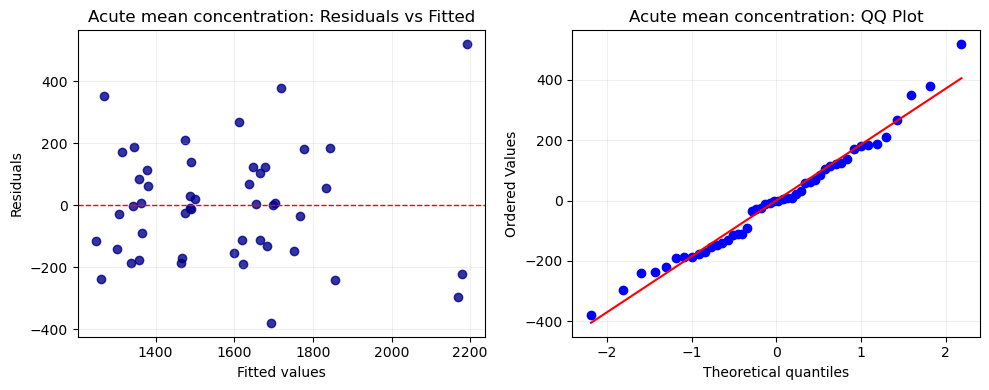

In [13]:
acute_grid = pd.DataFrame(
    [
        {
            'cultivar': cultivar,
            'heat_level': heat_level,
            'is_control': is_control,
        }
        for cultivar in CULTIVAR_ORDER
        for heat_level in HEAT_LEVEL_ORDER
        for is_control in CONDITION_ORDER
    ]
)
acute_pred = fixed_effect_predictions(acute_model, acute_grid)

fig_ac_pred, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
for ax, cultivar in zip(axes, CULTIVAR_ORDER):
    sub = acute_pred[acute_pred['cultivar'] == cultivar].copy()
    for is_control in CONDITION_ORDER:
        curve = sub[sub['is_control'] == is_control].copy()
        curve['heat_level'] = pd.Categorical(curve['heat_level'], categories=HEAT_LEVEL_ORDER, ordered=True)
        curve = curve.sort_values('heat_level')
        x = np.arange(len(curve))
        ax.plot(x, curve['pred'], marker='o', linewidth=2, color=CONDITION_COLORS[is_control], label=CONDITION_LABELS[is_control])
        ax.fill_between(x, curve['ci_low'], curve['ci_high'], color=CONDITION_COLORS[is_control], alpha=0.15)
    ax.set_xticks(np.arange(len(HEAT_LEVEL_ORDER)))
    ax.set_xticklabels(HEAT_LEVEL_ORDER)
    ax.set_title(cultivar)
    ax.set_xlabel('Heat level')
    ax.grid(alpha=0.2)
axes[0].set_ylabel('Model-estimated mean concentration')
axes[1].legend(title='Condition', loc='best')
fig_ac_pred.suptitle('Acute MixedLM Fitted Means with 95% CI', y=1.02)
fig_ac_pred.tight_layout()
fig_ac_pred.savefig(FIG_AC_PRED, dpi=180, bbox_inches='tight')
plt.show()

fig_ac_diag = diagnostic_figure(acute_model, 'Acute mean concentration')
fig_ac_diag.savefig(FIG_AC_DIAG, dpi=180, bbox_inches='tight')
plt.show()

## 7) Final step: write outputs

In [14]:
RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

lt_summary.to_csv(LT_SUMMARY_OUT, index=False)
acute_summary.to_csv(ACUTE_SUMMARY_OUT, index=False)
lt_coef.to_csv(LT_COEF_OUT, index=False)
acute_coef.to_csv(ACUTE_COEF_OUT, index=False)
lt_terms.to_csv(LT_WALD_OUT, index=False)
acute_terms.to_csv(ACUTE_WALD_OUT, index=False)

report_lines = [
    '# Phenolics Analysis Report',
    '',
    f'- Generated at: {datetime.now().isoformat(timespec="seconds")}',
    '- Outcome coding: all concentration differences are `heat - control`.',
    '- Acute A0/A0C rows were excluded from the main treatment-effect analysis.',
    '- Primary models: mixed-effects models on row-level mean concentration.',
    '',
    '## Inputs',
    f'- {relpath(RAW_XLSX)}',
    '',
    '## Preprocessing summary',
    f'- Raw rows: {len(raw)}',
    f'- True standards: {int(raw["is_standard"].sum())}',
    f'- Non-standard rows estimated: {len(concentrations)}',
    f'- Parsed successfully: {int(phen["experiment"].notna().sum())} / {len(phen)}',
    f'- Std-like non-standard rows retained: {len(std_like_nonstd)}',
    '',
    '## Pair counts',
    f'- Long-term complete pairs: {len(lt_complete)}',
    f'- Acute complete pairs: {len(acute_complete)}',
    '',
    '## Mixed-model findings',
    best_term_line(lt_terms, 'Long-term concentration model'),
    best_term_line(acute_terms, 'Acute concentration model'),
    '',
    '## Outputs',
    f'- {relpath(LT_SUMMARY_OUT)}',
    f'- {relpath(ACUTE_SUMMARY_OUT)}',
    f'- {relpath(LT_COEF_OUT)}',
    f'- {relpath(ACUTE_COEF_OUT)}',
    f'- {relpath(LT_WALD_OUT)}',
    f'- {relpath(ACUTE_WALD_OUT)}',
    f'- {relpath(FIG_LT_DIST)}',
    f'- {relpath(FIG_LT_MEAN)}',
    f'- {relpath(FIG_LT_PRED)}',
    f'- {relpath(FIG_LT_DIAG)}',
    f'- {relpath(FIG_AC_MEAN)}',
    f'- {relpath(FIG_AC_PRED)}',
    f'- {relpath(FIG_AC_DIAG)}',
    f'- {relpath(REPORT_OUT)}',
    '',
]
REPORT_OUT.write_text("\n".join(report_lines), encoding='utf-8')

saved_paths = [
    LT_SUMMARY_OUT,
    ACUTE_SUMMARY_OUT,
    LT_COEF_OUT,
    ACUTE_COEF_OUT,
    LT_WALD_OUT,
    ACUTE_WALD_OUT,
    FIG_LT_DIST,
    FIG_LT_MEAN,
    FIG_LT_PRED,
    FIG_LT_DIAG,
    FIG_AC_MEAN,
    FIG_AC_PRED,
    FIG_AC_DIAG,
    REPORT_OUT,
]

print('Saved outputs:')
for path in saved_paths:
    print('-', relpath(path))


Saved outputs:
- results/phenolics/phenolics_longterm_summary.csv
- results/phenolics/phenolics_acute_summary.csv
- results/phenolics/phenolics_longterm_mixedlm_coefficients.csv
- results/phenolics/phenolics_acute_mixedlm_coefficients.csv
- results/phenolics/phenolics_longterm_mixedlm_wald_terms.csv
- results/phenolics/phenolics_acute_mixedlm_wald_terms.csv
- results/phenolics/figures/phenolics_longterm_distribution.png
- results/phenolics/figures/phenolics_longterm_mean_se.png
- results/phenolics/figures/phenolics_longterm_mixedlm_fitted_means.png
- results/phenolics/figures/phenolics_longterm_diagnostics_mean_concentration.png
- results/phenolics/figures/phenolics_acute_mean_se.png
- results/phenolics/figures/phenolics_acute_mixedlm_fitted_means.png
- results/phenolics/figures/phenolics_acute_diagnostics_mean_concentration.png
- results/phenolics/phenolics_analysis_report.md
